In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Ladda ner data

In [3]:
import kagglehub
 
path = kagglehub.dataset_download(
    "jessemostipak/hotel-booking-demand"
)
 
print(path)

c:\Projekt Data Science\flotation-silica-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\malin\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1


## Läsa in data

In [4]:
df = pd.read_csv(os.path.join(path, "hotel_bookings.csv"))

## Första överblick

In [5]:
print(df.shape)
display(df.head())
display(df.info())
display(df.describe().T)
display(df.describe(include="object").T)

(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

None

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


C:\Users\malin\AppData\Local\Temp\ipykernel_15728\3204390653.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


### Kommentar till första överblick

119 390 bokningar och 32 kolumner.  
Två saker sticker ut i den numeriska sammanfattningen: adr har ett negativt minimum och ett maximum på 5 400, och adults har minimum 0. Det undersöks i nästa steg.

## Rimlighetskontroller

In [6]:
display(df[df["adr"] < 0])                                       # negativt pris
display(df["adr"].sort_values(ascending=False).head())           # extremt högt värde (~5400)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,No Deposit,273.0,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


48515     5400.0
111403     510.0
15083      508.0
103912     451.5
13142      450.0
Name: adr, dtype: float64

In [7]:
df["total_guests"] = df["adults"] + df["children"].fillna(0) + df["babies"]
noll = df[df["total_guests"] == 0]
print(len(noll), "bokningar utan gäster")
display(noll[["hotel", "is_canceled", "adr", "market_segment", "distribution_channel", "customer_type"]]
        .describe(include="all").T)

180 bokningar utan gäster


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,180,2,City Hotel,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,180.0,NaN,NaN,NaN,0.138889,0.346795,0.0,0.0,0.0,0.0,1.0
adr,180.0,NaN,NaN,NaN,10.4565,31.681635,0.0,0.0,0.0,0.0,200.0
market_segment,180,7,Online TA,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
distribution_channel,180,3,TA/TO,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_type,180,4,Transient,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Kommentar rimlighetskontroller

En bokning har negativt pris och en har 5 400 euro per natt, mer än tio gånger det näst högsta.  
**Båda tolkas som registreringsfel och tas bort**   

Bokningar med adr = 0 behålls, eftersom de kan vara gratisvistelser eller kompensationer.

180 bokningar (0,15 %) saknar gäster. Orsaken framgår inte av datan. Troligen är det administrativa poster eller ofullständig registrering. **De tas bort**

## Saknade värden och dubbletter

In [8]:
display(df.isna().sum().sort_values(ascending=False).head(10))
display(df.duplicated().sum())

company                      112593
agent                         16340
country                         488
children                          4
hotel                             0
arrival_date_week_number          0
arrival_date_day_of_month         0
is_canceled                       0
lead_time                         0
stays_in_week_nights              0
dtype: int64

np.int64(31994)

### Kommentar saknade värden och dubbletter

Fyra kolumner har saknade värden:

company (94 %): saknas när bokningen inte görs via ett företag. **Görs om till 0/1, "bokad via företag".**  
agent (14 %): saknas när ingen resebyrå används. **Sätts till 0 och behandlas som en egen kategori.**  
country (488 rader): **sätts till "Unknown". Används inte i modellen eftersom land kan vara läckage.**  
children (4 rader): **sätts till 0.**

31 994 rader (27 %) är identiska. Utan boknings-ID går det inte att avgöra om de är fel eller flera rum i samma bokning. De undersöks närmare längre fram.

In [9]:
# Hur stor andel avbokas?

df["is_canceled"].mean().round(2)

np.float64(0.37)

<Axes: xlabel='is_canceled', ylabel='lead_time'>

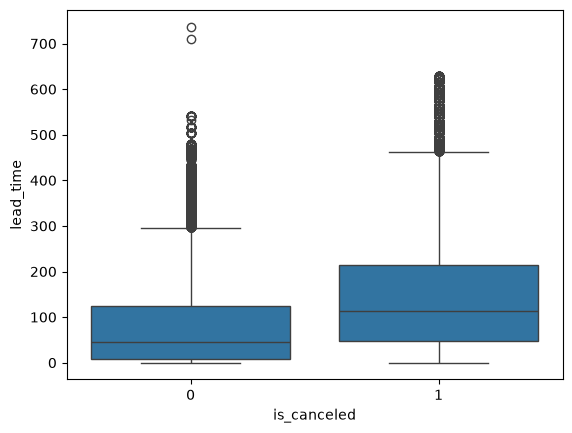

In [10]:
# Påverkar ledtiden om en bokning avbokas? (lead_time = antal dagar mellan bokning och ankomst)

sns.boxplot(data=df, x="is_canceled", y="lead_time")

<Axes: xlabel='arrival_date_month'>

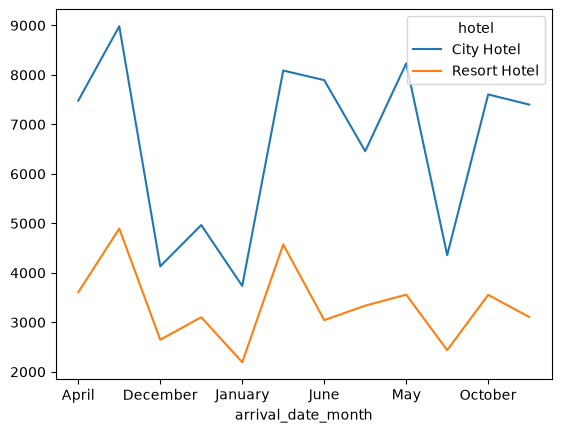

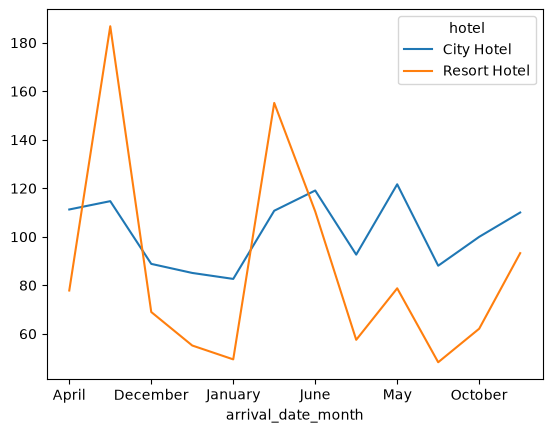

In [11]:
# Säsongsmönster för avbokningar

df.groupby(["arrival_date_month", "hotel"], observed=True).size().unstack().plot()
df.groupby(["arrival_date_month", "hotel"], observed=True)["adr"].mean().unstack().plot()


In [12]:
# Vilka faktorer påverkar om en bokning avbokas? (is_canceled = 1)

for col in ["deposit_type", "market_segment", "customer_type", "distribution_channel"]:
    print(df.groupby(col)["is_canceled"].agg(["mean", "count"]).sort_values("mean"), "\n")

                  mean   count
deposit_type                  
Refundable    0.222222     162
No Deposit    0.283770  104641
Non Refund    0.993624   14587 

                    mean  count
market_segment                 
Complementary   0.130552    743
Direct          0.153419  12606
Corporate       0.187347   5295
Aviation        0.219409    237
Offline TA/TO   0.343160  24219
Online TA       0.367211  56477
Groups          0.610620  19811
Undefined       1.000000      2 

                     mean  count
customer_type                   
Group            0.102253    577
Transient-Party  0.254299  25124
Contract         0.309617   4076
Transient        0.407463  89613 

                          mean  count
distribution_channel                 
Direct                0.174599  14645
GDS                   0.191710    193
Corporate             0.220758   6677
TA/TO                 0.410259  97870
Undefined             0.800000      5 



In [13]:
# Representerade länder (country)

df["country"].value_counts().head(10)

country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
ITA     3766
IRL     3375
BEL     2342
BRA     2224
NLD     2104
Name: count, dtype: int64

<Axes: >

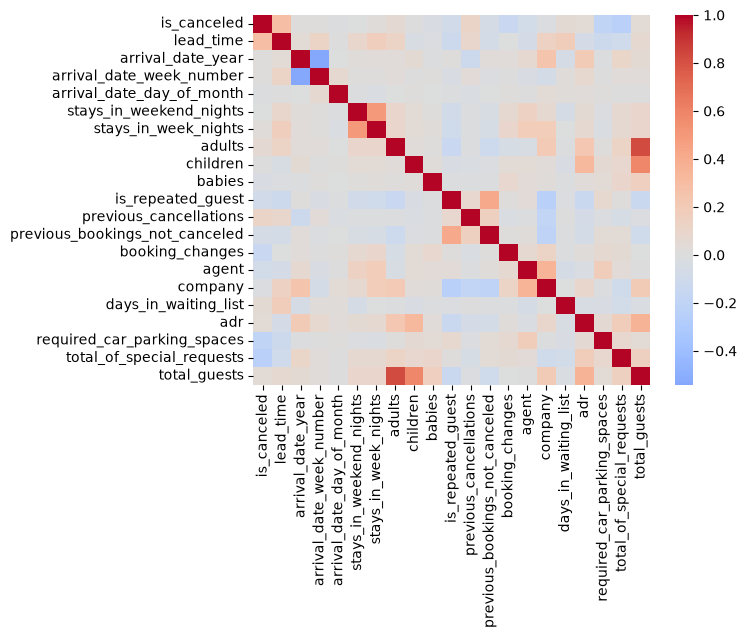

In [14]:
sns.heatmap(df.select_dtypes("number").corr(), cmap="coolwarm", center=0)

## Skapa booking_date

I datasetet finns inte bokningsdatum men det kan skapas uutifrån dessa variabler:

arrival_date_day_of_month -> Day of the month of the arrival date
arrival_date_month -> Month of arrival date with 12 categories: “January” to “December”
arrival_date_year -> Year of arrival date
lead_time -> Number of days that elapsed between the entering date of the booking into the PMS and the arrival date

In [15]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-"
    + df["arrival_date_month"].astype(str) + "-"
    + df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
)
df["booking_date"] = df["arrival_date"] - pd.to_timedelta(df["lead_time"], unit="D")
df["outcome_date"] = pd.to_datetime(df["reservation_status_date"])

# Rimlighetskontroll: utfallet ska inte ligga före bokningen
print((df["outcome_date"] < df["booking_date"]).sum())

0


In [ ]:
# Ifaaal vi vill sortera månaderna i rätt ordning kan vi göra om kolumnen till en kategorivariabel med ordning:

# month_order = ["January","February","March","April","May","June","July",
#                "August","September","October","November","December"]
# df["arrival_date_month"] = pd.Categorical(df.arrival_date_month, month_order, ordered=True)

In [16]:
df[["booking_date", "arrival_date", "outcome_date"]].agg(["min", "max"])

,booking_date,arrival_date,outcome_date
min,2013-06-24,2015-07-01,2014-10-17
max,2017-08-31,2017-08-31,2017-09-14


<Axes: xlabel='booking_date'>

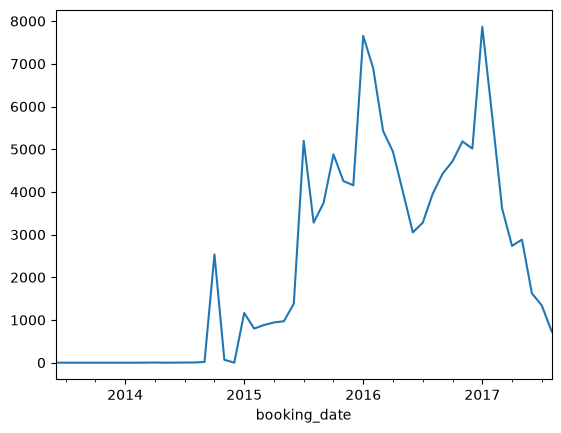

In [17]:
df.set_index("booking_date").resample("MS").size().plot()

In [18]:
okt = df[(df.booking_date >= "2014-09-01") & (df.booking_date < "2014-11-01")]
print(okt["hotel"].value_counts())
print(okt["is_canceled"].mean())
print(okt["deposit_type"].value_counts())
print(okt["agent"].value_counts().head())
print(okt.duplicated().mean())

hotel
City Hotel      2509
Resort Hotel      44
Name: count, dtype: int64
0.918918918918919
deposit_type
Non Refund    1562
No Deposit     991
Name: count, dtype: int64
agent
1.0     2065
6.0      350
5.0       74
21.0      16
40.0       9
Name: count, dtype: int64
0.917743830787309


In [19]:
canc_okt = okt[okt.is_canceled == 1]
print(canc_okt["outcome_date"].value_counts().head())   # avbokades de samma dag?
print(okt["lead_time"].describe())
print(okt["country"].value_counts().head())

# Hur mycket av hela datan följer samma mönster?
grupp = df[(df.agent == 1) & (df.deposit_type == "Non Refund")]
print(len(grupp), grupp["is_canceled"].mean(), grupp.duplicated().mean())

outcome_date
2015-01-01    761
2015-07-06    520
2015-07-02    419
2014-10-17    180
2015-07-23     93
Name: count, dtype: int64
count    2553.000000
mean      312.970623
std        34.814301
min       257.000000
25%       283.000000
50%       311.000000
75%       339.000000
max       414.000000
Name: lead_time, dtype: float64
country
PRT    2535
GBR      11
IRL       2
ESP       2
SWE       1
Name: count, dtype: int64
4072 1.0 0.9290275049115914


In [20]:
nr = df[df.deposit_type == "Non Refund"]
print(len(nr))
print(nr.groupby("agent").agg(antal=("is_canceled", "size"),
                              avbokade=("is_canceled", "mean"))
        .sort_values("antal", ascending=False).head(10))
print(nr.duplicated().mean(), (nr.country == "PRT").mean())

14587
       antal  avbokade
agent                 
1.0     4072       1.0
19.0     719       1.0
6.0      642       1.0
37.0     627       1.0
3.0      623       1.0
29.0     500       1.0
21.0     375       1.0
229.0    340       1.0
20.0     256       1.0
58.0     253       1.0
0.9288407486117776 0.9718242270514842


In [21]:
ovr = df[df.deposit_type != "Non Refund"]
print("Avbokningsgrad totalt:", df.is_canceled.mean(), "utan Non Refund:", ovr.is_canceled.mean())
print(ovr.groupby("hotel")["is_canceled"].mean())
print("PRT:", ovr[ovr.country == "PRT"].is_canceled.mean(),
      "övriga:", ovr[ovr.country != "PRT"].is_canceled.mean())
print("Dubbletter kvar:", ovr.duplicated().sum())

Avbokningsgrad totalt: 0.37041628277075134 utan Non Refund: 0.28367508563686156
hotel
City Hotel      0.304806
Resort Hotel    0.247046
Name: is_canceled, dtype: float64
PRT: 0.388766199802406 övriga: 0.23229481879270908
Dubbletter kvar: 18445


In [22]:
dup = ovr.duplicated(keep=False)
print("Andel dubbletter:", dup.mean())
print("Avbokningsgrad dubbletter:", ovr[dup].is_canceled.mean(),
      "övriga:", ovr[~dup].is_canceled.mean())
print(ovr[dup]["market_segment"].value_counts(normalize=True).head())


Andel dubbletter: 0.2466437029474347
Avbokningsgrad dubbletter: 0.3551007775929436 övriga: 0.2602908022392786
market_segment
Online TA        0.318117
Groups           0.297342
Offline TA/TO    0.280939
Direct           0.053929
Corporate        0.046037
Name: proportion, dtype: float64
